# Sensitivity Analysis
## How Model Assumptions Drive the Technical Premium

This notebook systematically varies one parameter at a time to understand
which assumptions have the greatest impact on the technical premium and
risk measures.

**Treaty:** 5M xs 1M per-occurrence XL (same as notebook 01)

**Parameters analysed:**
1. Claim frequency (λ)
2. Severity tail (σ)
3. Retention
4. Cost of capital
5. Frequency distribution: Poisson vs Negative Binomial

In [4]:
# Imports
from reinsure_pricing.frequency import PoissonFrequency, NegativeBinomialFrequency
from reinsure_pricing.severity import LognormalSeverity
from reinsure_pricing.treaties import ExcessOfLoss
from reinsure_pricing.simulation import MonteCarloEngine
from reinsure_pricing.risk_measures import compute_risk_measures
from reinsure_pricing.pricing import TechnicalPricer
from reinsure_pricing.plots import plot_sensitivity
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Base case parameters — held constant unless being varied
BASE_LAMBDA      = 120
BASE_MU          = 10.5
BASE_SIGMA       = 1.2
BASE_RETENTION   = 1_000_000
BASE_LIMIT       = 5_000_000
BASE_EXPENSE     = 0.05
BASE_PROFIT      = 0.08
BASE_COC         = 0.10
N_SIMS           = 50_000
SEED             = 42


def run_xl(retention=BASE_RETENTION, limit=BASE_LIMIT,
           lambda_=BASE_LAMBDA, sigma=BASE_SIGMA,
           expense=BASE_EXPENSE, profit=BASE_PROFIT,
           coc=BASE_COC):
    """
    Helper — run a full XL simulation and return (ecl, premium).
    All parameters default to the base case so callers only need
    to pass the one they are varying.
    """
    freq    = PoissonFrequency(lambda_=lambda_)
    sev     = LognormalSeverity(mu=BASE_MU, sigma=sigma)
    treaty  = ExcessOfLoss(retention=retention, limit=limit)
    engine  = MonteCarloEngine(freq, sev, treaty,
                               n_simulations=N_SIMS, random_state=SEED)
    results = engine.run()
    pricer  = TechnicalPricer(
        expected_ceded_loss=results.expected_ceded_loss,
        tvar_99=results.tvar_99,
        expense_load=expense,
        profit_load=profit,
        cost_of_capital=coc,
    )
    return results.expected_ceded_loss, pricer.technical_premium()

## 1. Sensitivity to Claim Frequency (λ)

We vary λ from 60 to 240 — representing portfolios from half to double
the base case volume. All other parameters are held constant.

**Expected behaviour:** higher λ → more claims per year → higher chance
of piercing the retention → higher ECL and premium.

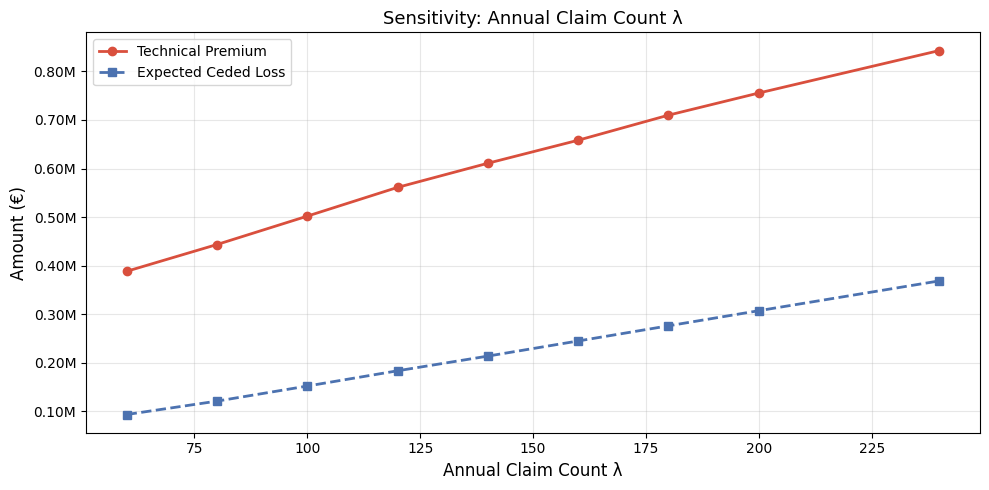

     λ             ECL         Premium    Loading
──────────────────────────────────────────────────
    60          93,665         388,497       4.15x
    80         121,248         443,638       3.66x
   100         152,269         502,063       3.30x
   120         183,706         561,262       3.06x
   140         213,942         610,957       2.86x
   160         245,095         658,332       2.69x
   180         276,295         709,954       2.57x
   200         307,389         755,528       2.46x
   240         368,781         842,993       2.29x


In [5]:
lambdas = [60, 80, 100, 120, 140, 160, 180, 200, 240]
ecls, premiums = zip(*[run_xl(lambda_=l) for l in lambdas])

fig = plot_sensitivity(
    parameter_values=lambdas,
    premiums=list(premiums),
    ecls=list(ecls),
    parameter_name="Annual Claim Count λ",
)
plt.show()

print(f"{'λ':>6} {'ECL':>15} {'Premium':>15} {'Loading':>10}")
print("─" * 50)
for l, e, p in zip(lambdas, ecls, premiums):
    print(f"{l:>6} {e:>15,.0f} {p:>15,.0f} {p/e:>10.2f}x")

## 2. Sensitivity to Severity Tail (σ)

We vary σ from 0.1 to 2.4, holding μ constant. A higher σ produces
a heavier-tailed lognormal — more extreme individual losses.

**Expected behaviour:** higher σ → heavier tail → more losses pierce
the retention and approach the limit → higher ECL, but disproportionately
higher TVaR → larger capital load → premium rises faster than ECL.

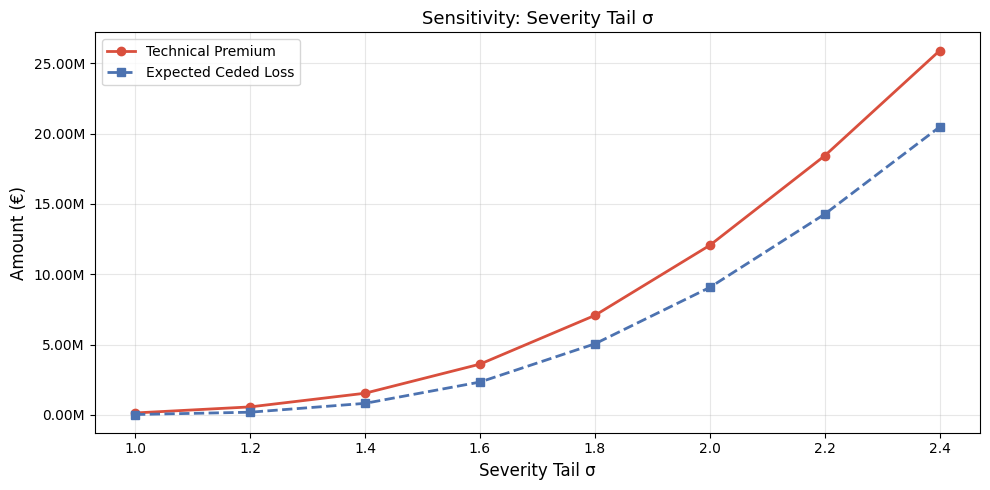

     σ             ECL         Premium    Loading
──────────────────────────────────────────────────
   1.0          19,735         130,470       6.61x
   1.2         183,706         561,262       3.06x
   1.4         813,656       1,533,232       1.88x
   1.6       2,328,617       3,602,746       1.55x
   1.8       5,048,087       7,071,139       1.40x
   2.0       9,062,079      12,058,907       1.33x
   2.2      14,280,393      18,432,541       1.29x
   2.4      20,483,406      25,913,635       1.27x


In [6]:
sigmas = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
ecls, premiums = zip(*[run_xl(sigma=s) for s in sigmas])

fig = plot_sensitivity(
    parameter_values=sigmas,
    premiums=list(premiums),
    ecls=list(ecls),
    parameter_name="Severity Tail σ",
)
plt.show()

print(f"{'σ':>6} {'ECL':>15} {'Premium':>15} {'Loading':>10}")
print("─" * 50)
for s, e, p in zip(sigmas, ecls, premiums):
    loading = f"{p/e:>10.2f}x" if e > 0 else "      N/A"
    print(f"{s:>6.1f} {e:>15,.0f} {p:>15,.0f} {loading}")

## 3. Sensitivity to Retention

We vary the retention from 500K to 4M, holding the limit at 5M.

**Expected behaviour:** higher retention → fewer losses pierce the layer
→ lower attachment probability → lower ECL and premium. The relationship
is non-linear — small retention increases have a large effect at low
retentions where many losses are just above the threshold.

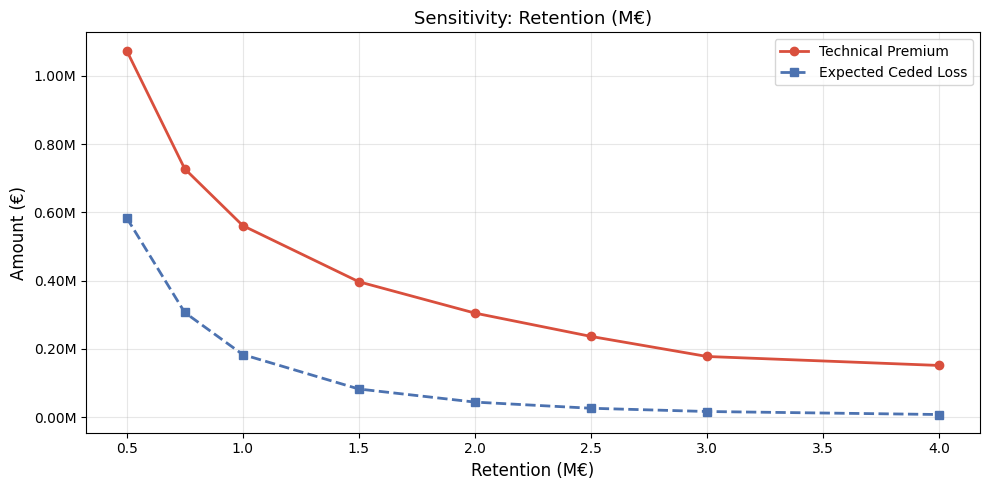

   Retention             ECL         Premium        ROL
───────────────────────────────────────────────────────
        0.50M         584,140       1,074,064     21.48%
        0.75M         306,867         727,669     14.55%
        1.00M         183,706         561,262     11.23%
        1.50M          82,653         396,789      7.94%
        2.00M          44,309         304,994      6.10%
        2.50M          26,295         236,640      4.73%
        3.00M          16,773         177,921      3.56%
        4.00M           7,947         151,641      3.03%


In [7]:
retentions = [500_000, 750_000, 1_000_000, 1_500_000,
              2_000_000, 2_500_000, 3_000_000, 4_000_000]
ecls, premiums = zip(*[run_xl(retention=r) for r in retentions])

fig = plot_sensitivity(
    parameter_values=[r/1e6 for r in retentions],
    premiums=list(premiums),
    ecls=list(ecls),
    parameter_name="Retention (M€)",
)
plt.show()

print(f"{'Retention':>12} {'ECL':>15} {'Premium':>15} {'ROL':>10}")
print("─" * 55)
for r, e, p in zip(retentions, ecls, premiums):
    print(f"{r/1e6:>12.2f}M {e:>15,.0f} {p:>15,.0f} {p/BASE_LIMIT:>10.2%}")

## 4. Sensitivity to Cost of Capital

We vary the cost of capital from 5% to 25%, holding all other parameters
constant. This shows how sensitive the premium is to the reinsurer's
internal hurdle rate.

**Expected behaviour:** higher cost of capital → larger capital charge
→ higher premium. The effect is amplified when TVaR >> ECL (heavy tail).

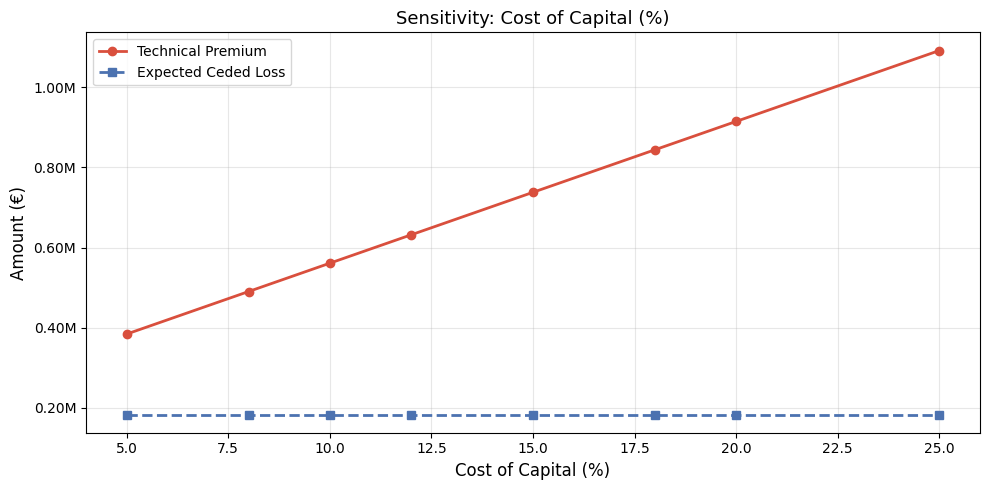

     CoC             ECL         Premium    Capital Load
───────────────────────────────────────────────────────
      5%         183,706         384,425         176,837
      8%         183,706         490,527         282,939
     10%         183,706         561,262         353,674
     12%         183,706         631,996         424,409
     15%         183,706         738,098         530,511
     18%         183,706         844,201         636,613
     20%         183,706         914,935         707,348
     25%         183,706       1,091,772         884,184


In [8]:
cocs = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25]
ecls, premiums = zip(*[run_xl(coc=c) for c in cocs])

fig = plot_sensitivity(
    parameter_values=[c * 100 for c in cocs],
    premiums=list(premiums),
    ecls=list(ecls),
    parameter_name="Cost of Capital (%)",
)
plt.show()

print(f"{'CoC':>8} {'ECL':>15} {'Premium':>15} {'Capital Load':>15}")
print("─" * 55)
base_ecl = ecls[0]
for c, e, p in zip(cocs, ecls, premiums):
    capital = p - e * (1 + BASE_EXPENSE + BASE_PROFIT)
    print(f"{c:>8.0%} {e:>15,.0f} {p:>15,.0f} {capital:>15,.0f}")

## 5. Poisson vs Negative Binomial Frequency

We compare the Poisson and Negative Binomial frequency models at the
same mean claim count (λ = μ = 120), varying the overdispersion
parameter φ of the Negative Binomial.

**Expected behaviour:** higher φ → more variance in claim counts →
heavier tail in the aggregate loss distribution → higher TVaR →
higher capital load → higher premium, even though ECL stays similar.

This demonstrates that **frequency distribution choice matters** — two
models with the same mean can produce materially different premiums.

In [9]:
# Base case: Poisson
freq_poisson  = PoissonFrequency(lambda_=120)
sev           = LognormalSeverity(mu=BASE_MU, sigma=BASE_SIGMA)
treaty        = ExcessOfLoss(retention=BASE_RETENTION, limit=BASE_LIMIT)

engine_p = MonteCarloEngine(freq_poisson, sev, treaty,
                             n_simulations=N_SIMS, random_state=SEED)
results_p = engine_p.run()
pricer_p  = TechnicalPricer(
    expected_ceded_loss=results_p.expected_ceded_loss,
    tvar_99=results_p.tvar_99,
    expense_load=BASE_EXPENSE,
    profit_load=BASE_PROFIT,
    cost_of_capital=BASE_COC,
)

# Negative Binomial at varying overdispersion
phis = [0.05, 0.10, 0.20, 0.30, 0.50]
nb_ecls, nb_premiums = [], []

for phi in phis:
    freq_nb = NegativeBinomialFrequency(mu=120, phi=phi)
    engine_nb = MonteCarloEngine(freq_nb, sev, treaty,
                                  n_simulations=N_SIMS, random_state=SEED)
    results_nb = engine_nb.run()
    pricer_nb  = TechnicalPricer(
        expected_ceded_loss=results_nb.expected_ceded_loss,
        tvar_99=results_nb.tvar_99,
        expense_load=BASE_EXPENSE,
        profit_load=BASE_PROFIT,
        cost_of_capital=BASE_COC,
    )
    nb_ecls.append(results_nb.expected_ceded_loss)
    nb_premiums.append(pricer_nb.technical_premium())

# Print comparison
print(f"{'Model':>25} {'ECL':>15} {'Premium':>15} {'TVaR 99%':>15}")
print("─" * 72)
print(f"{'Poisson (φ=0)':>25} "
      f"{results_p.expected_ceded_loss:>15,.0f} "
      f"{pricer_p.technical_premium():>15,.0f} "
      f"{results_p.tvar_99:>15,.0f}")

for phi, e, p in zip(phis, nb_ecls, nb_premiums):
    print(f"{'NegBin (φ='+str(phi)+')':>25} {e:>15,.0f} {p:>15,.0f}")

                    Model             ECL         Premium        TVaR 99%
────────────────────────────────────────────────────────────────────────
            Poisson (φ=0)         183,706         561,262       3,720,444
          NegBin (φ=0.05)         183,031         556,045
           NegBin (φ=0.1)         182,993         557,210
           NegBin (φ=0.2)         182,947         560,452
           NegBin (φ=0.3)         183,079         566,875
           NegBin (φ=0.5)         182,808         570,457


## 6. Summary — Parameter Ranking by Impact

Based on the sensitivity analyses above, the parameters that most
strongly drive the technical premium are:

| Rank | Parameter | Why it matters |
|---|---|---|
| 1 | Severity tail (σ) | Directly drives TVaR and capital load — small changes have large effects |
| 2 | Retention | Controls how many losses pierce the layer — non-linear effect |
| 3 | Claim frequency (λ) | More claims → higher chance of piercing retention |
| 4 | Frequency model (φ) | Overdispersion inflates TVaR without changing ECL much |
| 5 | Cost of capital | Linear effect — only matters when TVaR >> ECL |

**Key insight:** the severity tail assumption (σ) is the single most
important modelling choice for a high-excess XL layer. A actuary
should spend most calibration effort here — getting σ wrong by 0.2
can change the technical premium by more than changing the retention
by 500K.